# Restaurant Rating Prediction

## 1.Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style("whitegrid")

## 2.Load the Dataset

In [43]:
df = pd.read_csv('Dataset.csv')
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,Botswana Pula(P),No,No,No,No,3,4.4,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.0,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979333,14.540000,"Seafood, Filipino, Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.2,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.9,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.056532,14.572041,Filipino,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,532


## 3.Inspect Columns

In [44]:
print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

Column names:
 1. Restaurant ID
 2. Restaurant Name
 3. Country Code
 4. City
 5. Address
 6. Locality
 7. Locality Verbose
 8. Longitude
 9. Latitude
10. Cuisines
11. Average Cost for two
12. Currency
13. Has Table booking
14. Has Online delivery
15. Is delivering now
16. Switch to order menu
17. Price range
18. Aggregate rating
19. Rating color
20. Rating text
21. Votes


## 4.Data Types & Missing Values

In [45]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values,
    "Unique Values": df.nunique().values
})

display(dtype_summary)

,Column,Data Type,Non-Null Count,Missing Count,Unique Values
0,Restaurant ID,int64,9551,0,9551
1,Restaurant Name,str,9551,0,7446
2,Country Code,int64,9551,0,15
3,City,str,9551,0,141
4,Address,str,9551,0,8918
5,Locality,str,9551,0,1208
6,Locality Verbose,str,9551,0,1265
7,Longitude,float64,9551,0,8120
8,Latitude,float64,9551,0,8677
9,Cuisines,str,9542,9,1825


## 5.Handle Missing Values

In [46]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

print("Total missing values after handling:", df.isnull().sum().sum())

Total missing values after handling: 0


## 6.Remove Unrated Restaurants

In [47]:
unrated_count = (df['Aggregate rating'] == 0).sum()
print(f"Restaurants with no rating (Aggregate rating == 0): {unrated_count}")

df = df[df['Aggregate rating'] > 0]
print("Shape after removing unrated restaurants:", df.shape)

Restaurants with no rating (Aggregate rating == 0): 2148
Shape after removing unrated restaurants: (7403, 21)


## 7.Exploratory Data Analysis (EDA)

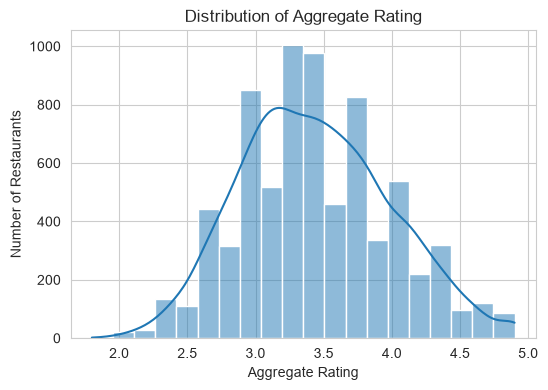

In [48]:
plt.figure(figsize=(6,4))
sns.histplot(df["Aggregate rating"], bins=20, kde=True)
plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

### Rating Category Breakdown

Rating text
Average      3737
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


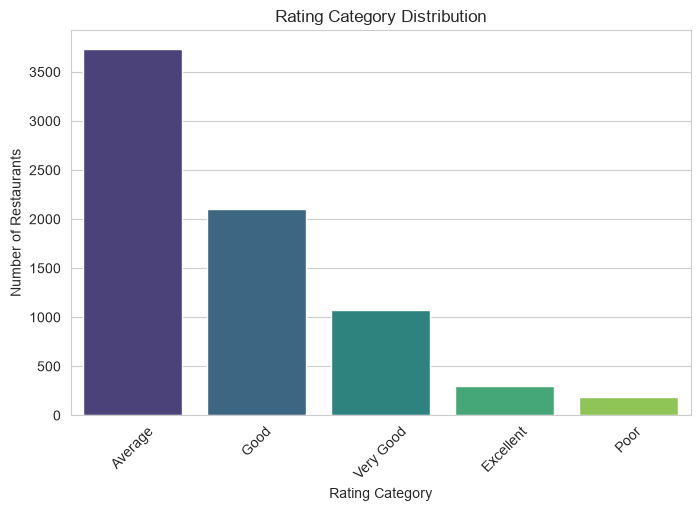

In [49]:
rating_text_counts = df['Rating text'].value_counts()
print(rating_text_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=rating_text_counts.index,
    y=rating_text_counts.values,
    hue=rating_text_counts.index,
    palette='viridis',
    legend=False
)
plt.title("Rating Category Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

### Summary Statistics

In [50]:
numerical_cols = ["Average Cost for two", "Aggregate rating", "Votes", "Price range"]
df[numerical_cols].describe()

,Average Cost for two,Aggregate rating,Votes,Price range
count,7403.000000,7403.000000,7403.000000,7403.000000
mean,1448.415102,3.440024,202.185060,1.970147
std,18303.524265,0.552195,479.195199,0.930611
min,0.000000,1.800000,4.000000,1.000000
25%,300.000000,3.000000,19.000000,1.000000
50%,500.000000,3.400000,60.000000,2.000000
75%,800.000000,3.800000,181.000000,3.000000
max,800000.000000,4.900000,10934.000000,4.000000


In [51]:
for col in numerical_cols:
    print(f"----- {col} -----")
    print("Mean:", round(df[col].mean(), 2))
    print("Median:", round(df[col].median(), 2))
    print("Standard Deviation:", round(df[col].std(), 2))

----- Average Cost for two -----
Mean: 1448.42
Median: 500.0
Standard Deviation: 18303.52
----- Aggregate rating -----
Mean: 3.44
Median: 3.4
Standard Deviation: 0.55
----- Votes -----
Mean: 202.19
Median: 60.0
Standard Deviation: 479.2
----- Price range -----
Mean: 1.97
Median: 2.0
Standard Deviation: 0.93


### Restaurants by Country

Country Code
1      6513
216     431
215      79
214      60
189      60
30       55
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


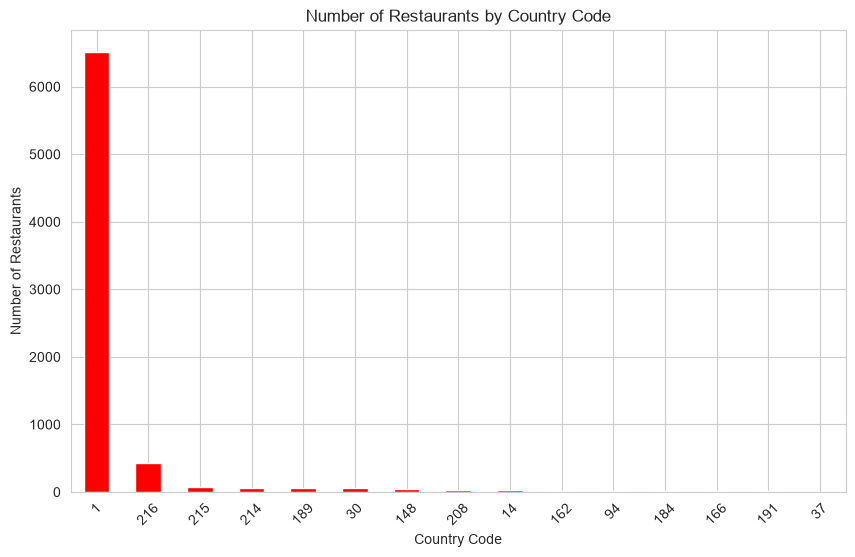

In [52]:
country_counts = df['Country Code'].value_counts()
print(country_counts)

plt.figure(figsize=(10, 6))
country_counts.plot(kind='bar', color='red')
plt.title("Number of Restaurants by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

### Top Cities by Restaurant Count

City
New Delhi       4048
Gurgaon          890
Noida            696
Faridabad        151
Ghaziabad         23
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


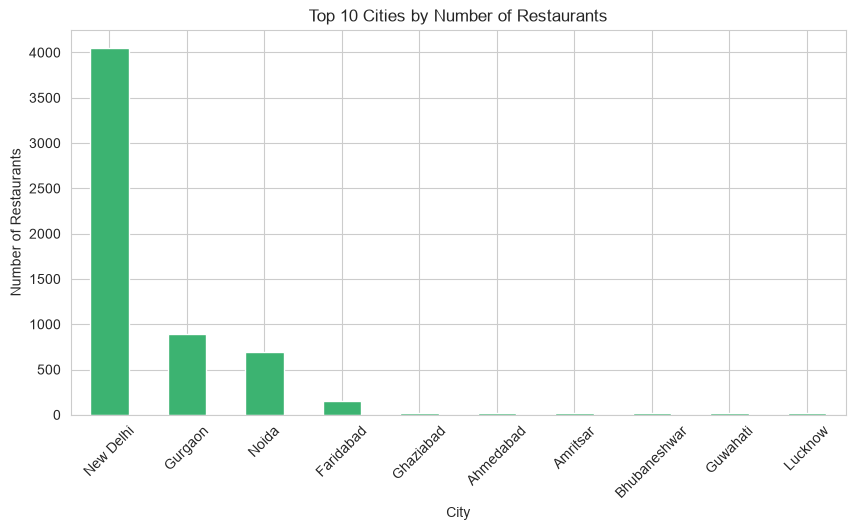

In [53]:
top_cities = df['City'].value_counts().head(10)
print(top_cities)

plt.figure(figsize=(10, 5))
top_cities.plot(kind='bar', color='mediumseagreen')
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

### Most Common Cuisines

Cuisines
North Indian    3017
Chinese         2184
Fast Food       1563
Mughlai          794
Italian          726
Continental      699
Cafe             634
Desserts         543
Bakery           536
South Indian     485
Name: count, dtype: int64


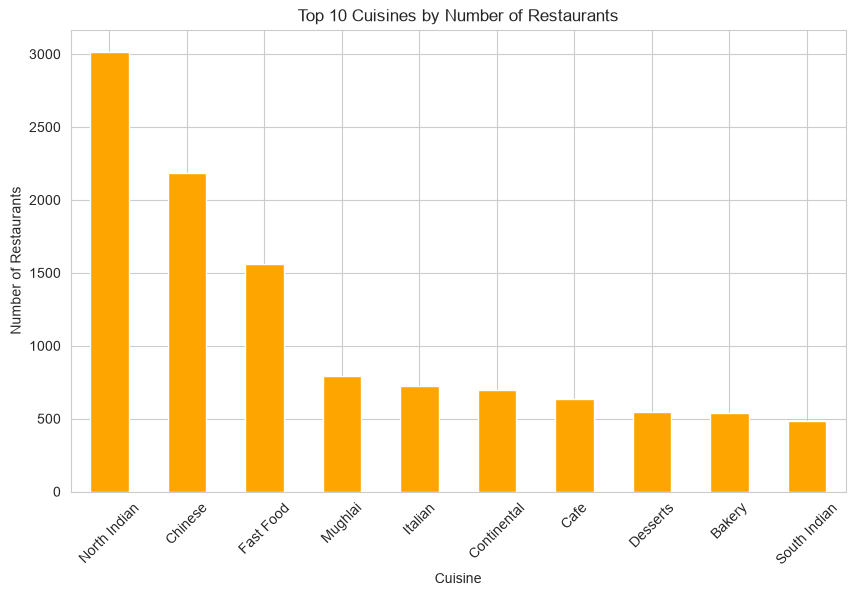

In [54]:
all_cuisines = df['Cuisines'].str.split(', ')
cuisine_list = all_cuisines.explode()

top_cuisines = cuisine_list.value_counts().head(10)
print(top_cuisines)

plt.figure(figsize=(10, 6))
top_cuisines.plot(kind='bar', color='orange')
plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

### Geographic Distribution

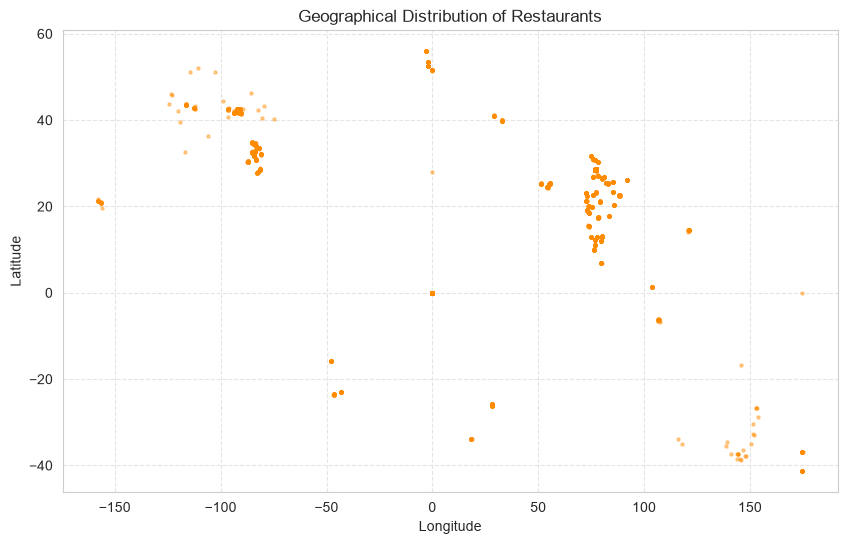

In [55]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df['Longitude'], df['Latitude'],
    s=5,
    alpha=0.4,
    color='darkorange'
)
plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Geographic Distribution by Rating

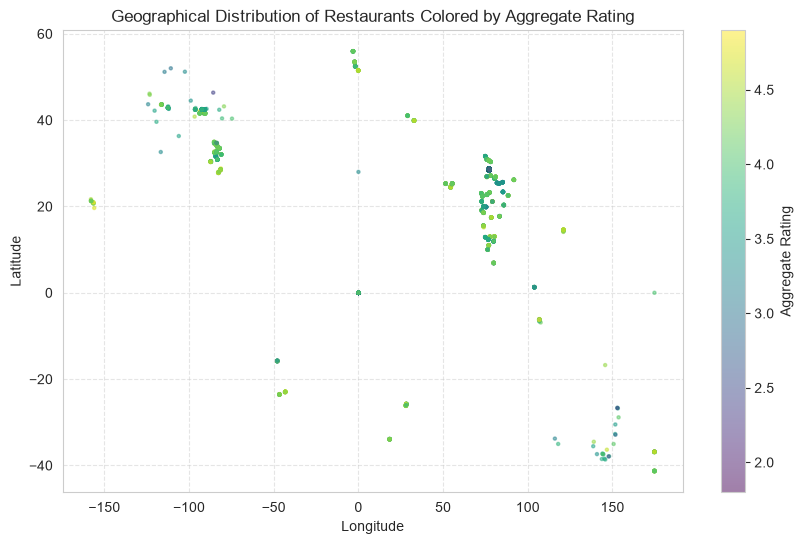

In [56]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['Aggregate rating'],
    cmap='viridis',
    s=5,
    alpha=0.5
)
plt.colorbar(scatter, label='Aggregate Rating')
plt.title("Geographical Distribution of Restaurants Colored by Aggregate Rating")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [57]:
location_corr = df[['Longitude', 'Latitude', 'Aggregate rating']].corr()
print(location_corr)

                  Longitude  Latitude  Aggregate rating
Longitude          1.000000 -0.097542         -0.291458
Latitude          -0.097542  1.000000         -0.179917
Aggregate rating  -0.291458 -0.179917          1.000000


### Table Booking & Online Delivery

In [58]:
table_booking_dist = df['Has Table booking'].value_counts(normalize=True) * 100
online_delivery_dist = df['Has Online delivery'].value_counts(normalize=True) * 100

table_booking_pct = table_booking_dist.get('Yes', 0)
online_delivery_pct = online_delivery_dist.get('Yes', 0)

print("Percentage of Restaurants with Table Booking:")
print(table_booking_dist.round(2))
print(f"\n-> {table_booking_pct:.2f}% of restaurants offer table booking.")

print("\nPercentage of Restaurants with Online Delivery:")
print(online_delivery_dist.round(2))
print(f"\n-> {online_delivery_pct:.2f}% of restaurants offer online delivery.")

Percentage of Restaurants with Table Booking:
Has Table booking
No     84.99
Yes    15.01
Name: proportion, dtype: float64

-> 15.01% of restaurants offer table booking.

Percentage of Restaurants with Online Delivery:
Has Online delivery
No     68.19
Yes    31.81
Name: proportion, dtype: float64

-> 31.81% of restaurants offer online delivery.


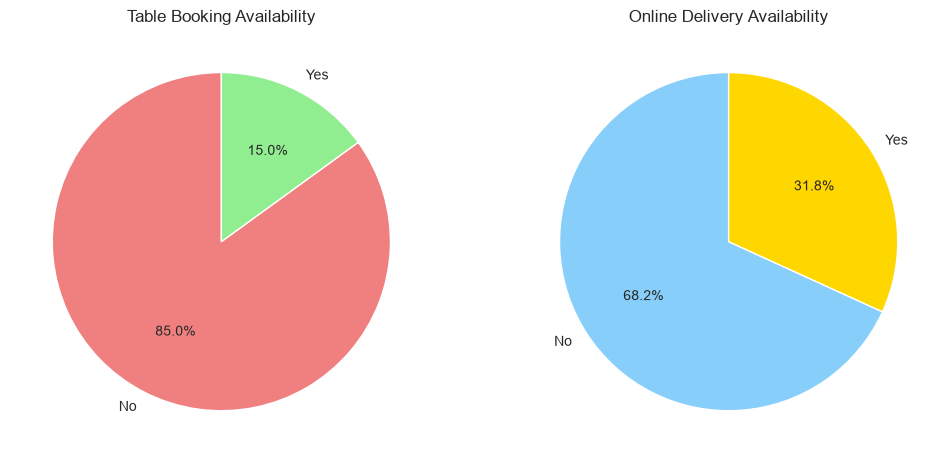

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(table_booking_dist.values,
            labels=table_booking_dist.index,
            autopct='%1.1f%%',
            colors=['lightcoral', 'lightgreen'],
            startangle=90)
axes[0].set_title("Table Booking Availability")

axes[1].pie(online_delivery_dist.values,
            labels=online_delivery_dist.index,
            autopct='%1.1f%%',
            colors=['lightskyblue', 'gold'],
            startangle=90)
axes[1].set_title("Online Delivery Availability")

plt.show()

Has Table booking
No     3.41
Yes    3.59
Name: Aggregate rating, dtype: float64


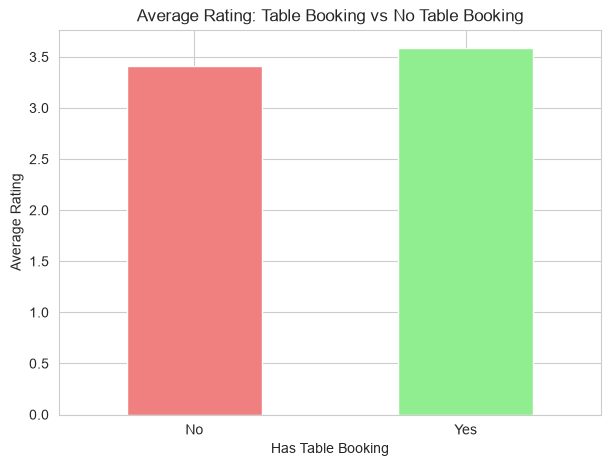

In [60]:
avg_rating_by_booking = df.groupby('Has Table booking')['Aggregate rating'].mean()
print(avg_rating_by_booking.round(2))

plt.figure(figsize=(7, 5))
avg_rating_by_booking.plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title("Average Rating: Table Booking vs No Table Booking")
plt.xlabel("Has Table Booking")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

Price range
1    23.615160
2    45.924013
3    29.788784
4     9.217391
Name: Has Online delivery, dtype: float64


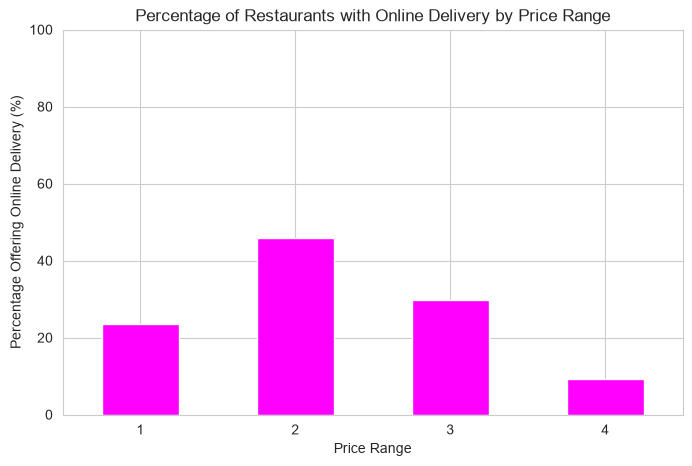

In [61]:
delivery_by_price_range = df.groupby('Price range')['Has Online delivery'].apply(lambda x: (x == 'Yes').mean() * 100)
print(delivery_by_price_range)

plt.figure(figsize=(8, 5))
delivery_by_price_range.plot(kind='bar', color='magenta')
plt.title("Percentage of Restaurants with Online Delivery by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage Offering Online Delivery (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

### Price Range Distribution


Price range
1    2744
2    2711
3    1373
4     575
Name: count, dtype: int64

The most common price range is: 1


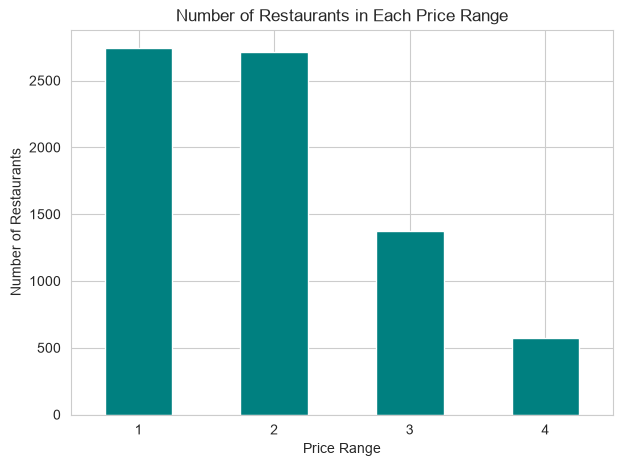

In [62]:
price_range_counts = df['Price range'].value_counts().sort_index()
print(price_range_counts)

most_common_price_range = price_range_counts.idxmax()
print("\nThe most common price range is:", most_common_price_range)

plt.figure(figsize=(7, 5))
price_range_counts.plot(kind='bar', color='teal')
plt.title("Number of Restaurants in Each Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.show()

Price range
1    3.24
2    3.38
3    3.78
4    3.89
Name: Aggregate rating, dtype: float64


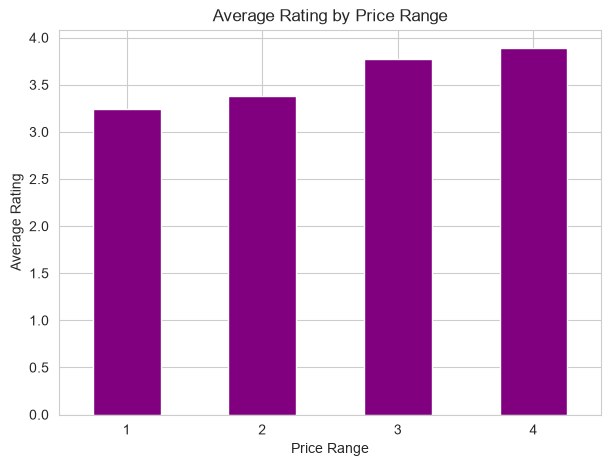

In [63]:
avg_rating_by_price_range = df.groupby('Price range')['Aggregate rating'].mean()
print(avg_rating_by_price_range.round(2))

plt.figure(figsize=(7, 5))
avg_rating_by_price_range.plot(kind='bar', color='purple')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

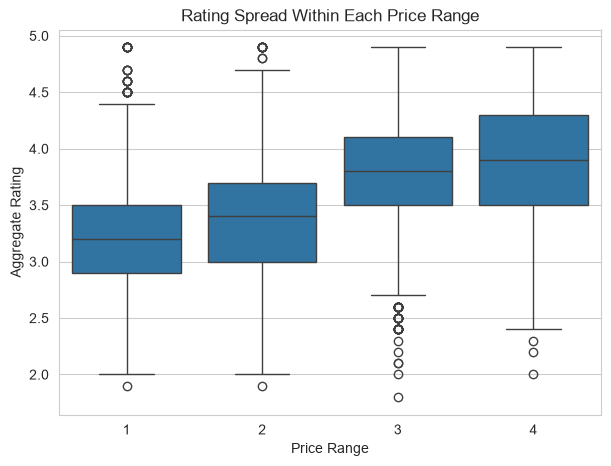

In [64]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Price range", y="Aggregate rating", data=df)
plt.title("Rating Spread Within Each Price Range")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.show()

### Rating Color Analysis

In [65]:
avg_rating_by_color = df.groupby('Rating color')['Aggregate rating'].mean().sort_values(ascending=False)
print(avg_rating_by_color.round(2))

best_color = avg_rating_by_color.idxmax()
print("\nThe rating color with the highest average rating is:", best_color)

Rating color
Dark Green    4.66
Green         4.17
Yellow        3.68
Orange        3.05
Red           2.30
Name: Aggregate rating, dtype: float64

The rating color with the highest average rating is: Dark Green


In [66]:
best_color_data = df[df['Rating color'] == best_color]

print(f"Price range distribution among '{best_color}'-rated restaurants:")
print(best_color_data['Price range'].value_counts().sort_index())

Price range distribution among 'Dark Green'-rated restaurants:
Price range
1     32
2     69
3    126
4     74
Name: count, dtype: int64


## 8.Feature Engineering

In [67]:
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)
df['Address Length'] = df['Address'].apply(len)

df[['Restaurant Name', 'Restaurant Name Length', 'Address', 'Address Length']].head()

,Restaurant Name,Restaurant Name Length,Address,Address Length
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [68]:
df['Table Booking Binary'] = (df['Has Table booking'] == 'Yes').astype(int)
df['Online Delivery Binary'] = (df['Has Online delivery'] == 'Yes').astype(int)

df[['Has Table booking', 'Table Booking Binary', 'Has Online delivery', 'Online Delivery Binary']].head()

,Has Table booking,Table Booking Binary,Has Online delivery,Online Delivery Binary
0,Yes,1,No,0
1,Yes,1,No,0
2,Yes,1,No,0
3,No,0,No,0
4,Yes,1,No,0


In [69]:
df['Number of Cuisines'] = df['Cuisines'].apply(lambda x: len(x.split(', ')))

df[['Cuisines', 'Number of Cuisines']].head()

,Cuisines,Number of Cuisines
0,"French, Japanese, Desserts",3
1,Japanese,1
2,"Seafood, Asian, Filipino, Indian",4
3,"Japanese, Sushi",2
4,"Japanese, Korean",2


Average number of cuisines per restaurant: 2.2


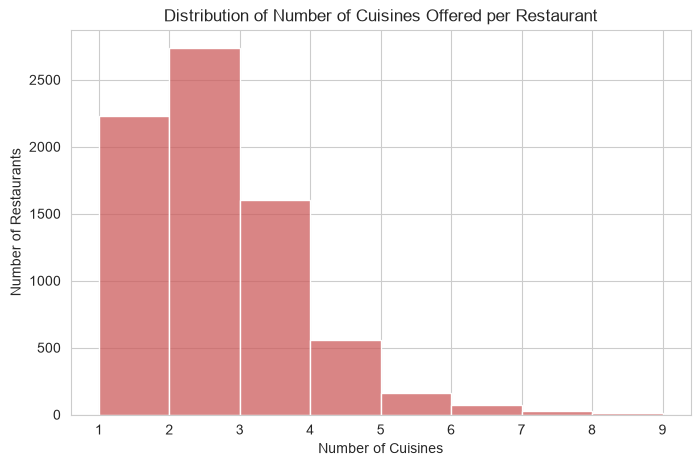

In [70]:
print("Average number of cuisines per restaurant:", round(df['Number of Cuisines'].mean(), 2))

plt.figure(figsize=(8, 5))
sns.histplot(
    df['Number of Cuisines'],
    bins=range(1, df['Number of Cuisines'].max() + 2),
    color='indianred'
)
plt.title("Distribution of Number of Cuisines Offered per Restaurant")
plt.xlabel("Number of Cuisines")
plt.ylabel("Number of Restaurants")
plt.show()

### Encoding Categorical Features & Selecting Model Inputs

In [71]:
city_freq_map = df['City'].value_counts().to_dict()
df['City Encoded'] = df['City'].map(city_freq_map)

country_freq_map = df['Country Code'].value_counts().to_dict()
df['Country Code Encoded'] = df['Country Code'].map(country_freq_map)

feature_cols = [
    'Average Cost for two', 'Price range', 'Votes',
    'Table Booking Binary', 'Online Delivery Binary',
    'Number of Cuisines', 'City Encoded', 'Country Code Encoded'
]

X = df[feature_cols]
y = df['Aggregate rating']

X.head()

,Average Cost for two,Price range,Votes,Table Booking Binary,Online Delivery Binary,Number of Cuisines,City Encoded,Country Code Encoded
0,1100,3,314,1,0,3,2,22
1,1200,3,591,1,0,1,2,22
2,4000,4,270,1,0,4,4,22
3,1500,4,365,0,0,2,4,22
4,1500,4,229,1,0,2,4,22


## 9.Train/Test Split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5922, 8)
Test set shape: (1481, 8)


## 10.Define Candidate Models

In [73]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

## 11.Train & Evaluate Models

In [74]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,MAE,RMSE,R2
0,Random Forest,0.274,0.371,0.555
1,Linear Regression,0.340,0.431,0.400
2,Decision Tree,0.362,0.501,0.189


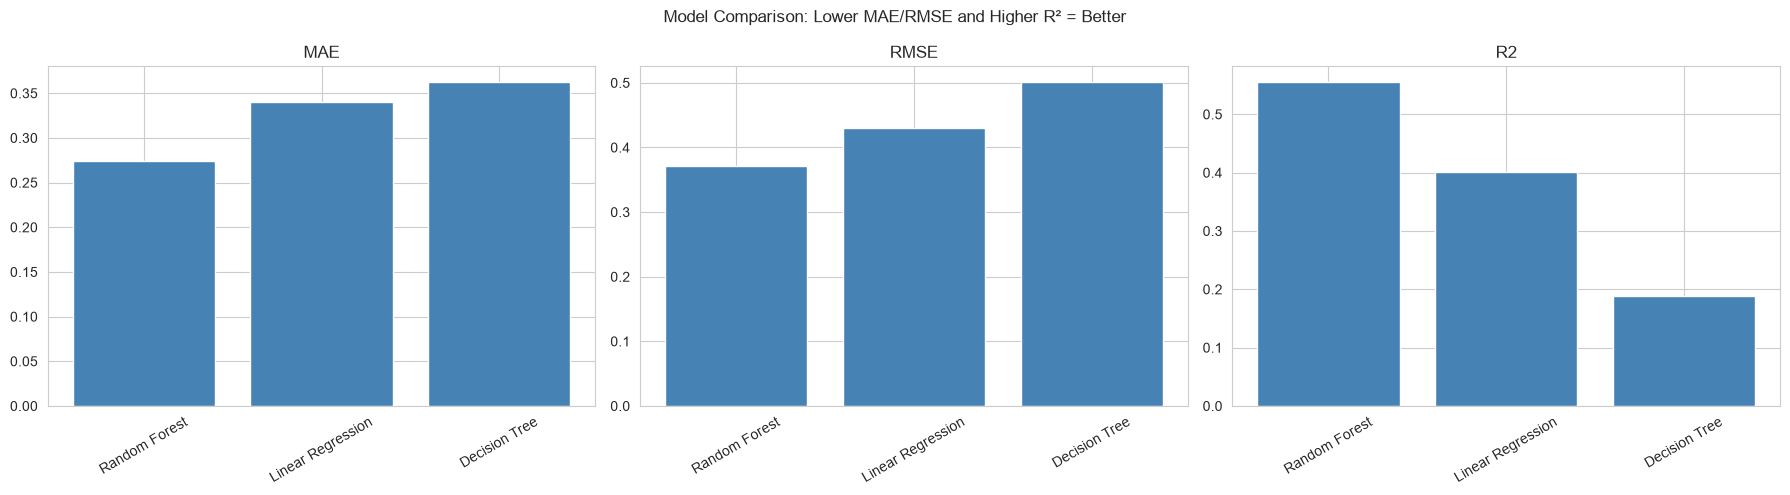

Best performing model: Random Forest


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(results_df['Model'], results_df[metric], color='steelblue')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Model Comparison: Lower MAE/RMSE and Higher R\u00b2 = Better")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")

## 12.Feature Importance


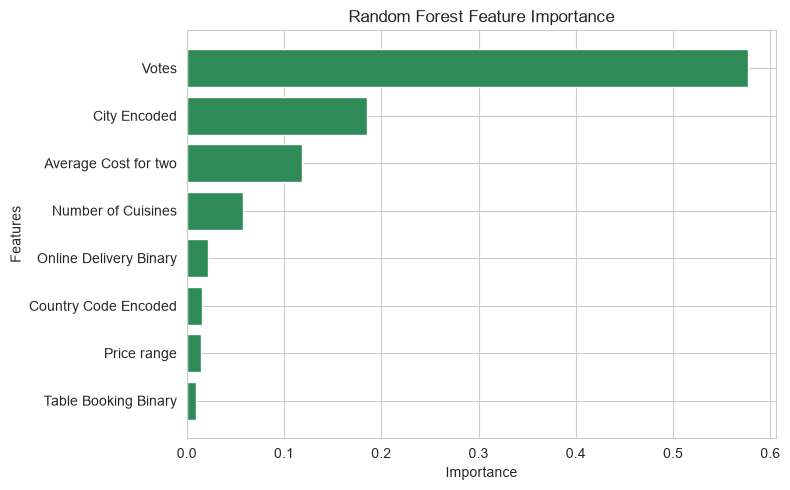

In [76]:
if hasattr(best_model, "feature_importances_"):
    values = best_model.feature_importances_
    title = f"{best_model_name} Feature Importance"
    xlabel = "Importance"

elif hasattr(best_model, "coef_"):
    values = best_model.coef_
    title = f"{best_model_name} Coefficients"
    xlabel = "Coefficient Value"

feature_data = pd.DataFrame({
    "Feature": feature_cols,
    "Value": values
})

feature_data = feature_data.sort_values(
    "Value",
    key=abs,
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_data["Feature"],
    feature_data["Value"],
    color="seagreen"
)

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## 13.Additional Analysis

### Cuisine Popularity

In [77]:
cuisine_df = df[['Cuisines', 'Aggregate rating', 'Votes']].copy()
cuisine_df['Cuisines'] = cuisine_df['Cuisines'].str.split(', ')
cuisine_exploded = cuisine_df.explode('Cuisines')

cuisine_exploded.head()

,Cuisines,Aggregate rating,Votes
0,French,4.8,314
0,Japanese,4.8,314
0,Desserts,4.8,314
1,Japanese,4.5,591
2,Seafood,4.4,270


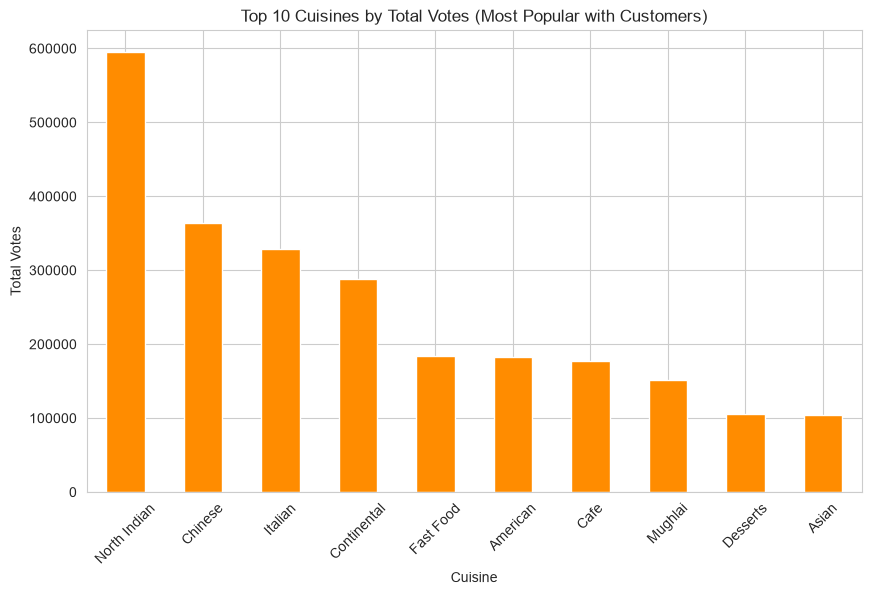

Cuisines
North Indian    595194
Chinese         363890
Italian         329230
Continental     288213
Fast Food       183665
American        183106
Cafe            177494
Mughlai         151784
Desserts        105781
Asian           104298
Name: Votes, dtype: int64

In [78]:
cuisine_votes = (
    cuisine_exploded.groupby('Cuisines')['Votes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
cuisine_votes.plot(kind='bar', color='darkorange')
plt.title("Top 10 Cuisines by Total Votes (Most Popular with Customers)")
plt.xlabel("Cuisine")
plt.ylabel("Total Votes")
plt.xticks(rotation=45)
plt.show()

cuisine_votes

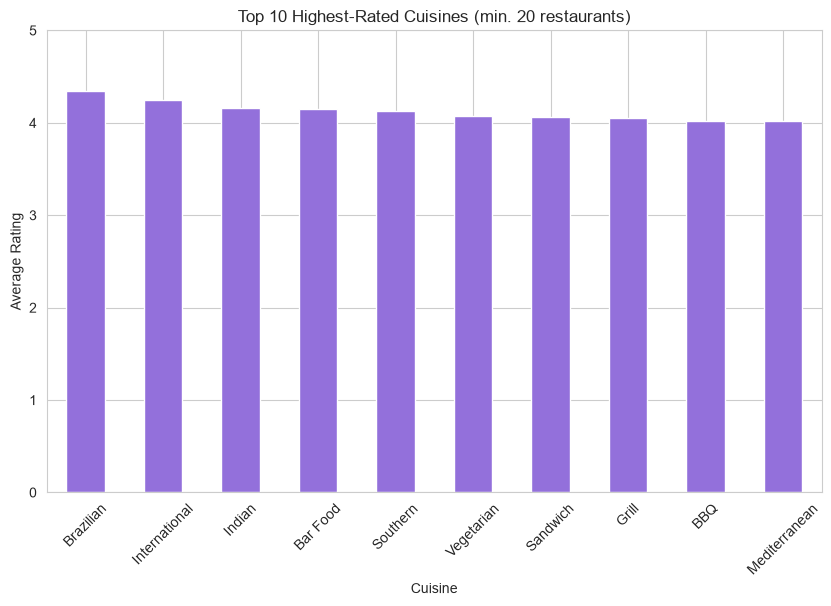

Cuisines
Brazilian        4.34
International    4.25
Indian           4.16
Bar Food         4.15
Southern         4.13
Vegetarian       4.07
Sandwich         4.07
Grill            4.06
BBQ              4.03
Mediterranean    4.02
Name: Aggregate rating, dtype: float64

In [79]:
cuisine_counts = cuisine_exploded['Cuisines'].value_counts()
eligible_cuisines = cuisine_counts[cuisine_counts >= 20].index

cuisine_avg_rating = (
    cuisine_exploded[cuisine_exploded['Cuisines'].isin(eligible_cuisines)]
    .groupby('Cuisines')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
cuisine_avg_rating.plot(kind='bar', color='mediumpurple')
plt.title("Top 10 Highest-Rated Cuisines (min. 20 restaurants)")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.show()

cuisine_avg_rating.round(2)

### Feature Correlation Heatmap

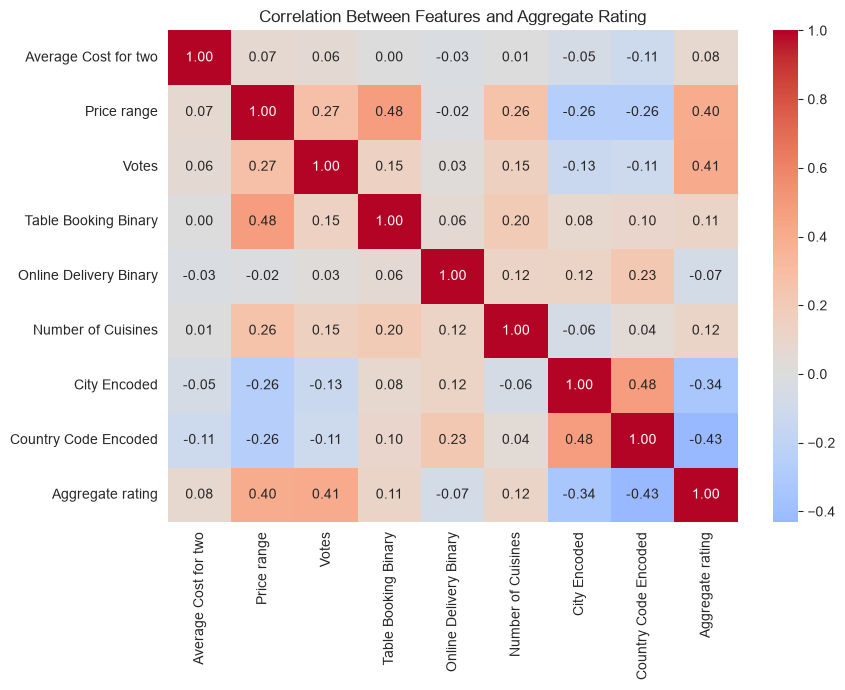

In [80]:
corr_features = feature_cols + ['Aggregate rating']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Between Features and Aggregate Rating")
plt.tight_layout()
plt.show()

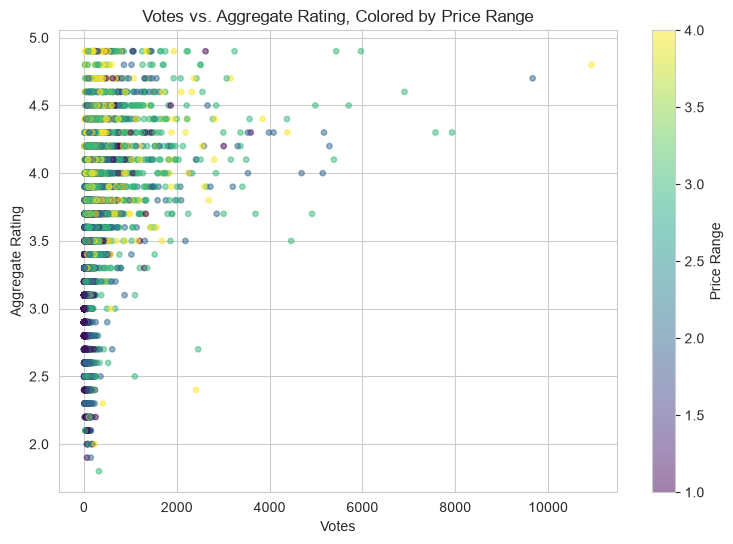

In [81]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['Votes'], df['Aggregate rating'],
    c=df['Price range'], cmap='viridis', alpha=0.5, s=15
)
plt.colorbar(scatter, label='Price Range')
plt.title("Votes vs. Aggregate Rating, Colored by Price Range")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.show()

### Highest-Rated Cities

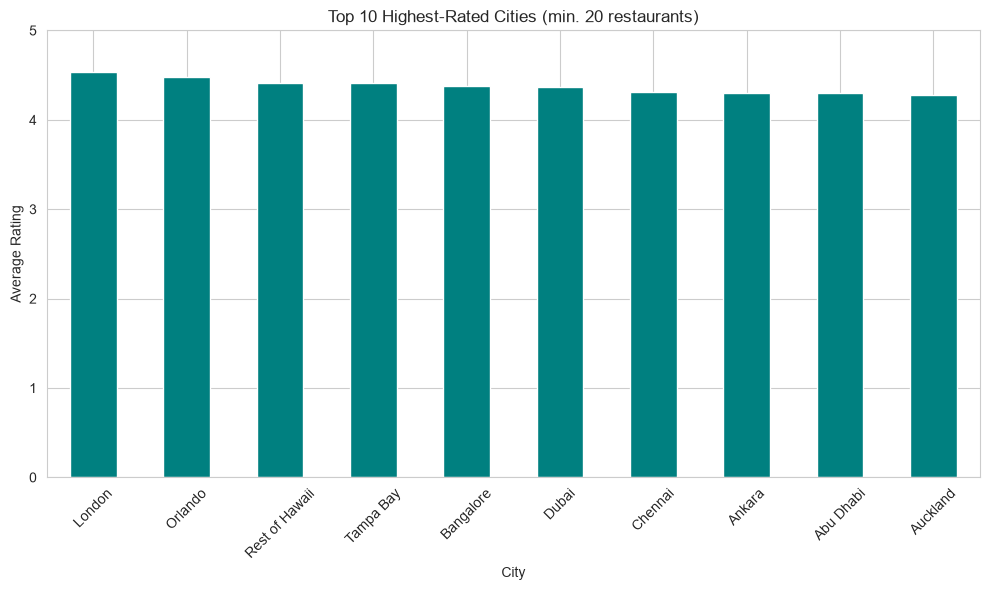

City
London            4.54
Orlando           4.47
Rest of Hawaii    4.41
Tampa Bay         4.41
Bangalore         4.38
Dubai             4.37
Chennai           4.31
Ankara            4.30
Abu Dhabi         4.30
Auckland          4.28
Name: Aggregate rating, dtype: float64

In [82]:
city_counts = df['City'].value_counts()
eligible_cities = city_counts[city_counts >= 20].index
city_avg_rating = (
    df[df['City'].isin(eligible_cities)]
    .groupby('City')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
city_avg_rating.plot(kind='bar', color='teal')
plt.title("Top 10 Highest-Rated Cities (min. 20 restaurants)")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

city_avg_rating.round(2)